In [ ]:
import pandas as pd
import numpy as np
from os import getcwd, listdir, path
import matplotlib.pyplot as plt
import sys
import ast
from glob import glob

import fitness.data_generating_process as dgp
import fitness.soga_fitness_SCM as soga_fitness_SCM
import fitness.interventions as interventions

In [ ]:
# Read all pareto_fitness.txt files under results/causal_skills_tests and build aggregated stats
program = 'complex'
ex_name = program
base_dir = path.join('..', 'results', ex_name)
pattern = path.join(base_dir, '**', 'stats.tsv')

# Read ONLY the column best_fitness from all stats.tsv files, change the value tensor(-1000000.) to -1000000.0, and FOR EACH ROW compute mean, std, median and interquartile ranges (25, 75)
# and save the results in a new dataframe with columns: mean, std, median, q25, q75.Do not consider interventions.

files = glob(pattern, recursive=True)
dfs = []
for file in files:
    df = pd.read_csv(file, sep='\t')
    df['best_fitness'] = df['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    dfs.append(df[['best_fitness']])

# for each row, compute mean, std, median, q25 and q75
results = []
for i in range(len(dfs[0])):
    values = [df['best_fitness'].iloc[i] for df in dfs]
    mean = np.mean(values)
    std = np.std(values)
    median = np.median(values)
    q25 = np.percentile(values, 25)
    q75 = np.percentile(values, 75)
    results.append({'mean': mean, 'std': std, 'median': median, 'q25': q25, 'q75': q75})

results_df = pd.DataFrame(results)
print(results_df)


               mean            std          median             q25  \
0    -700146.637817  458033.579720 -1000000.000000 -1000000.000000   
1    -700128.355126  458061.504837 -1000000.000000 -1000000.000000   
2    -500342.047632  499658.117414  -500913.067990 -1000000.000000   
3    -300315.847181  458050.844841     -482.630378  -750253.543086   
4    -200387.783718  399806.173421     -450.867334     -957.409219   
...             ...            ...             ...             ...   
1496    -153.442900      13.195579     -152.285604     -158.099281   
1497    -153.438464      13.196987     -152.285604     -158.099281   
1498    -153.438464      13.196987     -152.285604     -158.099281   
1499    -153.418224      13.188741     -152.285604     -157.947486   
1500    -153.227111      13.124487     -152.285576     -156.514176   

                q75  
0    -250460.747534  
1    -250359.136657  
2       -461.102045  
3       -297.522252  
4       -297.522252  
...             ...  
1496 

In [ ]:
vars, scm = dgp.get_vars(program)
real_program = dgp.get_real_program(program)
baseline_program = dgp.get_baseline_program(program)
#real_dataset = dgp.generate_interventional_dataset(scm, vars, 1000)

real_dataset_file = f'fitness/datasets/{program}.csv'
real_dataset = np.loadtxt(real_dataset_file, delimiter=',')

likelihood = soga_fitness_SCM.compute_likelihood(real_program, vars, real_dataset)
likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program, vars, real_dataset)

likelihood_intervened = 0
likelihood_base_intervened = 0
print(f'Likelihood of real program: {likelihood}')
print(f'\nLikelihood of baseline program: {likelihood_base}')
interventions_list = dgp.get_intervention_list(program)
for var, value in interventions_list:
    dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
    data_intervened = np.loadtxt(dataset_file, delimiter=',')
    program_intervened = interventions.apply_intervention_to_program(real_program, var, value)
    baseline_program_intervened = interventions.apply_intervention_to_program(baseline_program, var, value)
    interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
    interventional_likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program_intervened, vars, data_intervened)
    likelihood_intervened += interventional_likelihood
    likelihood_base_intervened += interventional_likelihood_base


likelihood = likelihood + likelihood_intervened
likelihood_base = likelihood_base + likelihood_base_intervened
print(f'Total likelihood of real program: {likelihood}')
print(f'Total likelihood of baseline program: {likelihood_base}')


Likelihood of real program: -10.758546548439934

Likelihood of baseline program: -15.004638313941996
Total likelihood of real program: -95.57558224219996
Total likelihood of baseline program: -148.2121321711155


In [ ]:
# between all the files, find the one with best likelihood and print the corresponding program
best_likelihood = -np.inf
best_program = None
for file in files:
    df = pd.read_csv(file, sep='\t')
    df['best_fitness'] = df['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    max_likelihood = df['best_fitness'].max()
    if max_likelihood > best_likelihood:
        best_likelihood = max_likelihood
        best_program = file 
print(f'Best likelihood: {best_likelihood}')
#print(f'Best program file: {best_program}')

#in the folder where the best stats.tsv file is, print the content of the best.txt file
best_program_file = best_program.replace('stats.tsv', 'best.txt')
with open(best_program_file, 'r') as f:
    best_program_content = f.read()
print(f'Best program content:\n{best_program_content}')

Best likelihood: -134.86465163381166
Best program content:
Generation:
1500

Phenotype:
7
V1 = uniform([+5.8e+0, 8.0e-0], 2);
V2 = +V1 * +1.3e-2;
V2 = V2 + gm([6.3e-0, +6.7e-2, 5.9e-2], [7.0e+2, +4.8e+0, 2.8e+0]);
V3 = +V1 * +7.6e-1 * +5.5e-1;
V3 = V3 + gm([4.5e+0, +1.0e-0, 1.0e+0]);
V4 = +V1;
V4 = V4 + gm([0.3e+1, +5.2e+0, 3.0e+0]);
V5 = -1.6e+0;
V5 = V5 + uniform([-9.7e-0, 7.0e+2], 2);

Pre-processed Program
:F = uniform([5.800000, 13.800000], 2);TEMP0 = 0.013 * F;W = TEMP0;W = W + gm([0.008920, 0.991080], [0.067, 4.8], [0.059, 2.8]);TEMP1 = 0.418 * F;C = TEMP1;C = C + gm([1.000000], [1], [1]);T = F;T = T + gm([1.000000], [5.2], [3]);P = 0;P = P - 1.6;P = P + uniform([-9.700000, 690.300000], 2);Genotype:
[221, 246, 464, 461, 120, 494, 18, 365, 238, 28, 30, 258, 468, 330, 351, 60, 194, 360, 183, 114, 460, 272, 224, 335, 132, 248, 201, 233, 403, 140, 202, 45, 399, 136, 146, 3, 93, 255, 261, 436, 456, 147, 163, 122, 318, 65, 339, 417, 35, 456, 46, 467, 50, 258, 104, 269, 184, 44, 468, 2

In [ ]:
# Read all pareto_fitness.txt files under results/causal_skills_tests and build aggregated stats
ex_name_independent = ex_name + '_independent'
base_dir_independent = path.join('..', 'results', ex_name_independent)
pattern_independent = path.join(base_dir_independent, '**', 'stats.tsv')

# Read ONLY the column best_fitness from all stats.tsv files, change the value tensor(-1000000.) to -1000000.0, and FOR EACH ROW compute mean, std, median and interquartile ranges (25, 75)
# and save the results in a new dataframe with columns: mean, std, median, q25, q75.Do not consider interventions.

files_independent = glob(pattern_independent, recursive=True)
dfs = []
for file in files_independent:
    df = pd.read_csv(file, sep='\t')
    df['best_fitness'] = df['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    dfs.append(df[['best_fitness']])

# for each row, compute mean, std, median, q25 and q75
results = []
for i in range(len(dfs[0])):
    values = [df['best_fitness'].iloc[i] for df in dfs]
    mean = np.mean(values)
    std = np.std(values)
    median = np.median(values)
    q25 = np.percentile(values, 25)
    q75 = np.percentile(values, 75)
    results.append({'mean': mean, 'std': std, 'median': median, 'q25': q25, 'q75': q75})

results_df_independent = pd.DataFrame(results)
print(results_df_independent)


            mean         std      median         q25         q75
0    -388.863526  271.095692 -292.286508 -342.203185 -264.410354
1    -291.167689   65.397585 -261.535661 -302.318670 -256.568768
2    -255.856328   24.766499 -256.291853 -260.168718 -239.140249
3    -246.613952   19.388785 -246.770668 -249.859039 -232.697414
4    -237.402768    9.377321 -239.005039 -246.337769 -229.578655
...          ...         ...         ...         ...         ...
1496 -162.508468    0.732046 -162.751144 -163.109954 -162.017263
1497 -162.508468    0.732046 -162.751144 -163.109954 -162.017263
1498 -162.508468    0.732046 -162.751144 -163.109954 -162.017263
1499 -162.508468    0.732046 -162.751144 -163.109954 -162.017263
1500 -162.508468    0.732046 -162.751144 -163.109954 -162.017263

[1501 rows x 5 columns]


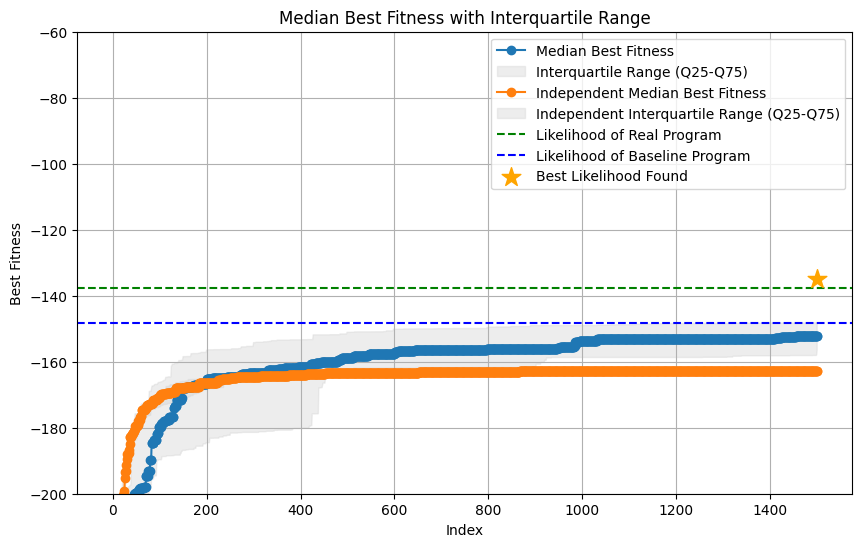

In [ ]:
# Plot results_df median with shaded interquartile range
plt.figure(figsize=(10, 6))
plt.plot(results_df.index, results_df['median'], 'o-', label='Median Best Fitness')
plt.fill_between(
    results_df.index,
    results_df['q25'],
    results_df['q75'],
    color='lightgray',
    alpha=0.4,
    label='Interquartile Range (Q25-Q75)'
)

plt.plot(results_df_independent.index, results_df_independent['median'], 'o-', label='Independent Median Best Fitness')
plt.fill_between(
    results_df_independent.index,
    results_df_independent['q25'],
    results_df_independent['q75'],
    color='lightgray',
    alpha=0.4,
    label='Independent Interquartile Range (Q25-Q75)'
)


plt.title('Median Best Fitness with Interquartile Range')
plt.xlabel('Index')
plt.ylabel('Best Fitness')
plt.ylim(-200, -60)

# Add a horizontal line for the likelihood of the real program and the baseline program
plt.axhline(y=likelihood, color='g', linestyle='--', label='Likelihood of Real Program')
plt.axhline(y=likelihood_base, color='b', linestyle='--', label='Likelihood of Baseline Program')

# Add a point for the best likelihood found in the files with the shape of a star and color orange
plt.scatter(len(results_df)-1, best_likelihood, color='orange', label='Best Likelihood Found', zorder=5, marker='*', s=200)

plt.legend()

plt.grid()
plt.show()

In [ ]:
no_int_ex_name = ex_name + '_no_interventions'

# Read all best.txt files under results/chain_no_interventions and compute the likelihood of the program in each best.txt file (it's between "Pre-processed Program \n :" and "Tree:")
pattern_no_int = path.join('..', 'results', no_int_ex_name, '**', 'best.txt')
files_no_int = glob(pattern_no_int, recursive=True)
likelihoods_no_int = []
likelihoods_no_int_no_interventions = []
for file in files_no_int:
    with open(file, 'r') as f:
        content = f.read()
    program_start = content.find('Pre-processed Program') + len('Pre-processed Program')
    program_end = content.find('Genotype:')
    program_str = content[program_start:program_end].strip()
    #remove the : at the beginning
    program_str = program_str.lstrip(':')
    #print(f'Program string:\n{program_str}')
    #program_ast = ast.literal_eval(program_str)
    likelihood_no_int_no_interventions = soga_fitness_SCM.compute_likelihood(program_str, vars, real_dataset)
    #print(f'Likelihood of program found without interventions: {likelihood_no_int}')
    interventions_list = dgp.get_intervention_list(program)
    likelihood_no_int = 0
    for var, value in interventions_list:
        dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
        data_intervened = np.loadtxt(dataset_file, delimiter=',')
        program_intervened = interventions.apply_intervention_to_program(program_str, var, value)
        #print(f'Program intervened:\n{program_intervened}')
        try:
            interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
        except Exception as e:
            print(f'Error computing likelihood for intervention {var}={value}: {e}')
            interventional_likelihood = -1000000.0
        #print(f'Interventional likelihood for intervention {var}={value}: {interventional_likelihood}')
        likelihood_no_int += interventional_likelihood

    likelihoods_no_int.append(likelihood_no_int)
    likelihoods_no_int_no_interventions.append(likelihood_no_int_no_interventions)

likelihoods_no_int = [x + y for x, y in zip(likelihoods_no_int, likelihoods_no_int_no_interventions)]
print(f'Likelihoods of programs found without interventions: {likelihoods_no_int_no_interventions}')
print(f'Likelihoods of programs found interventions: {likelihoods_no_int}')

Likelihoods of programs found without interventions: [tensor(-14.1961), tensor(-14.6778), tensor(-15.9014), tensor(-17.3901), tensor(-14.3393), tensor(-14.1886), tensor(-13.2162), tensor(-15.0522), tensor(-15.8274), tensor(-15.4910)]
Likelihoods of programs found interventions: [tensor(-192.7566), tensor(-157.8938), tensor(-6000062.4923), tensor(-168.8625), tensor(-147.5973), tensor(-150.6094), tensor(-2000104.4395), tensor(-153.7914), tensor(-158.6059), tensor(-2000133.2458)]


In [ ]:
# between all the files, find the one with best likelihood and print the corresponding program
base_dir_no_interventions = path.join('..', 'results', no_int_ex_name)
pattern_no_interventions = path.join(base_dir_no_interventions, '**', 'stats.tsv')

# Read ONLY the column best_fitness from all stats.tsv files, change the value tensor(-1000000.) to -1000000.0, and FOR EACH ROW compute mean, std, median and interquartile ranges (25, 75)
# and save the results in a new dataframe with columns: mean, std, median, q25, q75.Do not consider interventions.

files_no_interventions = glob(pattern_no_interventions, recursive=True)
dfs_no_int = []
for file in files_no_interventions:
    df_no_int = pd.read_csv(file, sep='\t')
    df_no_int['best_fitness'] = df_no_int['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    dfs_no_int.append(df_no_int[['best_fitness']])

# for each row, compute mean, std, median, q25 and q75
results_no_int = []
for i in range(len(dfs_no_int[0])):
    values = [df_no_int['best_fitness'].iloc[i] for df_no_int in dfs_no_int]
    mean = np.mean(values)
    std = np.std(values)
    median = np.median(values)
    q25 = np.percentile(values, 25)
    q75 = np.percentile(values, 75)
    results_no_int.append({'mean': mean, 'std': std, 'median': median, 'q25': q25, 'q75': q75})

results_df_no_interventions = pd.DataFrame(results_no_int)
print(results_df_no_interventions)


best_likelihood_no_interventions= -np.inf
best_program_no_interventions = None
for file in files_no_interventions:
    df_no_int = pd.read_csv(file, sep='\t')
    df_no_int['best_fitness'] = df_no_int['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    max_likelihood_no_interventions = df_no_int['best_fitness'].max()
    if max_likelihood_no_interventions > best_likelihood_no_interventions:
        best_likelihood_no_interventions = max_likelihood_no_interventions
        best_program_no_interventions = file 
print(f'Best likelihood: {best_likelihood_no_interventions}')
#print(f'Best program file: {best_program_no_interventions}')

#in the folder where the best stats.tsv file is, print the content of the best.txt file
best_program_file = best_program_no_interventions.replace('stats.tsv', 'best.txt')
with open(best_program_file, 'r') as f:
    best_program_content = f.read()
print(f'Best program content:\n{best_program_content}')

           mean        std     median        q25        q75
0    -49.640441  13.232349 -46.024171 -51.899863 -40.398547
1    -42.163822   5.334123 -40.984353 -47.615263 -38.426298
2    -36.942367   7.182087 -34.488684 -42.033425 -31.314581
3    -34.431680   5.267999 -32.980035 -37.113366 -30.683408
4    -31.580520   2.666590 -30.875492 -33.309375 -29.882132
...         ...        ...        ...        ...        ...
1496 -15.028032   1.116793 -14.864995 -15.743328 -14.231924
1497 -15.028032   1.116793 -14.864995 -15.743328 -14.231924
1498 -15.028032   1.116793 -14.864995 -15.743328 -14.231924
1499 -15.028032   1.116793 -14.864995 -15.743328 -14.231924
1500 -15.028015   1.116804 -14.864995 -15.743328 -14.231882

[1501 rows x 5 columns]
Best likelihood: -13.216239991047251
Best program content:
Generation:
1500

Phenotype:
65
V1 = gm([3.4e+2, +5.8e+0, 4.0e+0], [7.5e-0, -6.8e-2, 5.2e-0]);
V2 = -V1 * -9.2e-1;
V2 = V2 + gm([4.5e+2, +9.9e-0, 2.2e-0], [0.6e-0, +6.5e+2, 5.4e-1], [0.7e-1, -8.0e

In [ ]:
import torch
# Read all best.txt files under results/chain_no_interventions and compute the likelihood of the program in each best.txt file (it's between "Pre-processed Program \n :" and "Tree:")
pattern = path.join('..', 'results', ex_name, '**', 'best.txt')
files = glob(pattern, recursive=True)
likelihoods = []
likelihoods_no_interventions = []
for file in files:
    with open(file, 'r') as f:
        content = f.read()
    program_start = content.find('Pre-processed Program') + len('Pre-processed Program')
    program_end = content.find('Genotype:')
    program_str = content[program_start:program_end].strip()
    #remove the : at the beginning
    program_str = program_str.lstrip(':')
    #print(f'Program string:\n{program_str}')
    #program_ast = ast.literal_eval(program_str)
    likelihood_no_interventions = soga_fitness_SCM.compute_likelihood(program_str, vars, real_dataset)
    likelihoods_no_interventions.append(likelihood_no_interventions)
    #print(f'Likelihood of program found without interventions: {likelihood_no_int}')
    interventions_list = dgp.get_intervention_list(program)
    likelihood = 0
    for var, value in interventions_list:
        dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
        data_intervened = np.loadtxt(dataset_file, delimiter=',')
        program_intervened = interventions.apply_intervention_to_program(program_str, var, value)
        #print(f'Program intervened:\n{program_intervened}')
        interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
        #print(f'Interventional likelihood for intervention {var}={value}: {interventional_likelihood}')
        #print(f'Interventional likelihood for intervention {var}={value}: {interventional_likelihood}')
        likelihood += interventional_likelihood
        #print(f'Likelihood after intervention {var}={value}: {likelihood}')

    likelihoods.append(likelihood)
print(len(likelihoods))
#sum the two lists element-wise
likelihoods = [x + y for x, y in zip(likelihoods, likelihoods_no_interventions)]
print(f'Likelihoods of programs found interventions: {likelihoods}')
print(f'Likelihoods of programs found without interventions: {likelihoods_no_interventions}')

print(len(likelihoods))
print(len(likelihoods_no_interventions))

10
Likelihoods of programs found interventions: [tensor(-147.8700), tensor(-136.6710), tensor(-134.8647), tensor(-184.0431), tensor(-155.6845), tensor(-162.5445), tensor(-149.2314), tensor(-156.7907), tensor(-150.0922), tensor(-154.4790)]
Likelihoods of programs found without interventions: [tensor(-16.1523), tensor(-14.8813), tensor(-14.9264), tensor(-20.3273), tensor(-16.5699), tensor(-17.8402), tensor(-16.3902), tensor(-16.5725), tensor(-16.3817), tensor(-16.7059)]
10
10


In [ ]:
import torch
print("Likelihood:")
print(torch.mean(torch.tensor(likelihoods_no_interventions)))
print("Interventional Likelihood")
print(torch.mean(torch.tensor(likelihoods)))
print(likelihoods)
print("Likelihood without interventions:")
print(torch.mean(torch.tensor(likelihoods_no_int_no_interventions)))
print("Interventional Likelihood without interventions:")
print(torch.mean(torch.tensor(likelihoods_no_int)))
likelihoods_no_int_filtered = [x for x in likelihoods_no_int if x > -10000.0]
print(likelihoods_no_int_filtered)

Likelihood:
tensor(-16.6748)
Interventional Likelihood
tensor(-153.2271)
[tensor(-147.8700), tensor(-136.6710), tensor(-134.8647), tensor(-184.0431), tensor(-155.6845), tensor(-162.5445), tensor(-149.2314), tensor(-156.7907), tensor(-150.0922), tensor(-154.4790)]
Likelihood without interventions:
tensor(-15.0280)
Interventional Likelihood without interventions:
tensor(-1000143.0294)
[tensor(-192.7566), tensor(-157.8938), tensor(-168.8625), tensor(-147.5973), tensor(-150.6094), tensor(-153.7914), tensor(-158.6059)]


/tmp/ipykernel_1281957/1375267174.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([likelihoods_no_interventions, likelihoods_no_int_no_interventions], labels=['With Interventions', 'Without Interventions'])


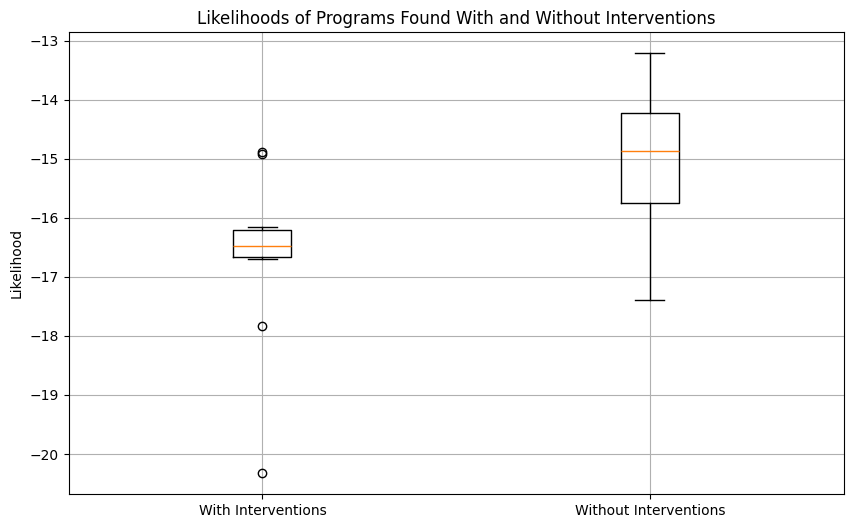

In [ ]:
#create a boxplot with mean and variance of likelihoods_no_interventions and likelihoods_no_int_no_interventions
plt.figure(figsize=(10, 6))

plt.boxplot([likelihoods_no_interventions, likelihoods_no_int_no_interventions], labels=['With Interventions', 'Without Interventions'])
plt.title('Likelihoods of Programs Found With and Without Interventions')

plt.ylabel('Likelihood')
plt.grid()
plt.show()

/tmp/ipykernel_1281957/1934761811.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([likelihoods, likelihoods_no_int_filtered], labels=['With Interventions', 'Without Interventions'])


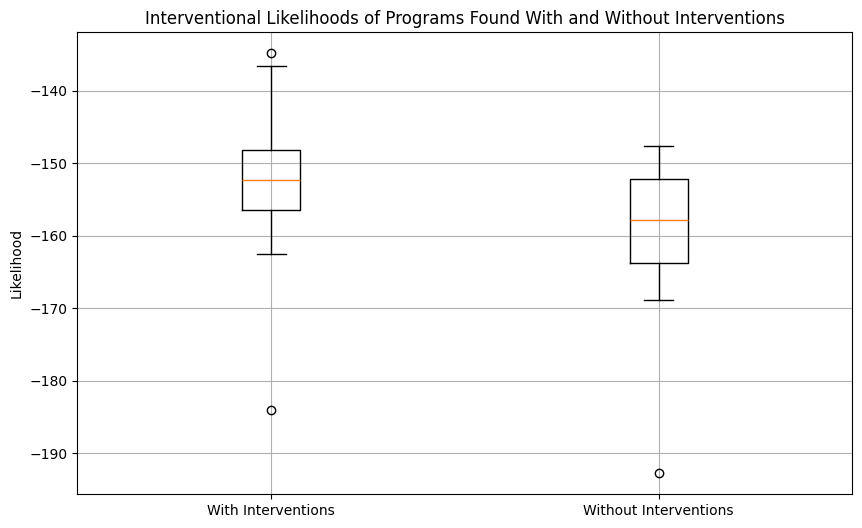

In [ ]:
#create a boxplot with mean and variance of likelihoods_no_interventions and likelihoods_no_int_no_interventions
plt.figure(figsize=(10, 6))

plt.boxplot([likelihoods, likelihoods_no_int_filtered], labels=['With Interventions', 'Without Interventions'])
plt.title('Interventional Likelihoods of Programs Found With and Without Interventions')

#plt.boxplot([likelihoods_no_interventions, likelihoods_no_int_no_interventions], labels=['With Interventions', 'Without Interventions'])
#plt.title('Likelihoods of Programs Found With and Without Interventions')

plt.ylabel('Likelihood')
plt.grid()
plt.show()

Number of evolutionary steps aggregated: 0


ValueError: need at least one array to concatenate

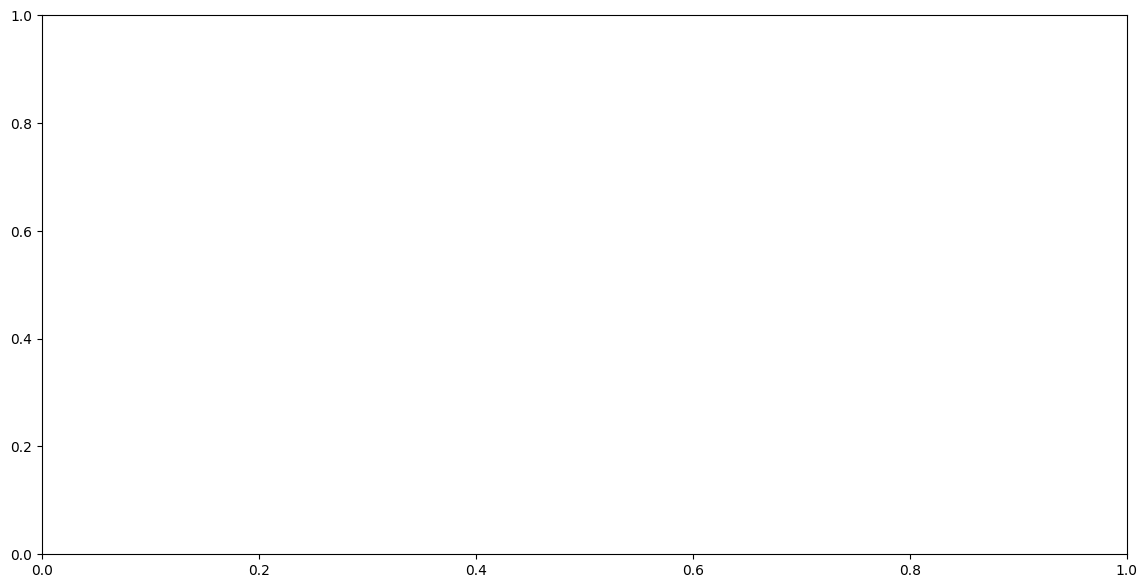

In [ ]:
from collections import Counter
import re

pattern = path.join('..', 'results', ex_name, '**', 'structure.csv')
files = glob(pattern, recursive=True)

# structure_counts_aggregated[step] = Counter({structure_index: total_count_across_all_runs})
structure_counts_aggregated = []

for file in files:
    df = pd.read_csv(file, header=None)

    for step_idx, row in df.iterrows():
        while len(structure_counts_aggregated) <= step_idx:
            structure_counts_aggregated.append(Counter())

        row_text = str(row.iloc[0]).strip()
        if row_text == '' or row_text.lower() == 'nan':
            continue

        indices = [idx for idx in re.split(r'\s+', row_text) if idx != '']
        structure_counts_aggregated[step_idx].update(indices)

print(f'Number of evolutionary steps aggregated: {len(structure_counts_aggregated)}')

# Build a consistent list of all structures that appeared
all_structures = sorted({s for c in structure_counts_aggregated for s in c.keys()}, key=lambda x: int(x))
n_steps = len(structure_counts_aggregated)
x = np.arange(n_steps)

# percentages[i, t] = percentage of structure i at step t
percentages = np.zeros((len(all_structures), n_steps), dtype=float)

for t, counter in enumerate(structure_counts_aggregated):
    total = sum(counter.values())
    if total == 0:
        continue
    for i, structure in enumerate(all_structures):
        percentages[i, t] = 100.0 * counter.get(structure, 0) / total

# Stacked area chart
plt.figure(figsize=(14, 7))
plt.stackplot(x, *percentages, labels=[f'Structure {s}' for s in all_structures], alpha=0.9)
plt.title('Structure Percentage Across Evolutionary Steps')
plt.xlabel('Evolutionary Step')
plt.ylabel('Percentage')
plt.xlim(0, n_steps - 1)
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

Number of evolutionary steps aggregated: 1502


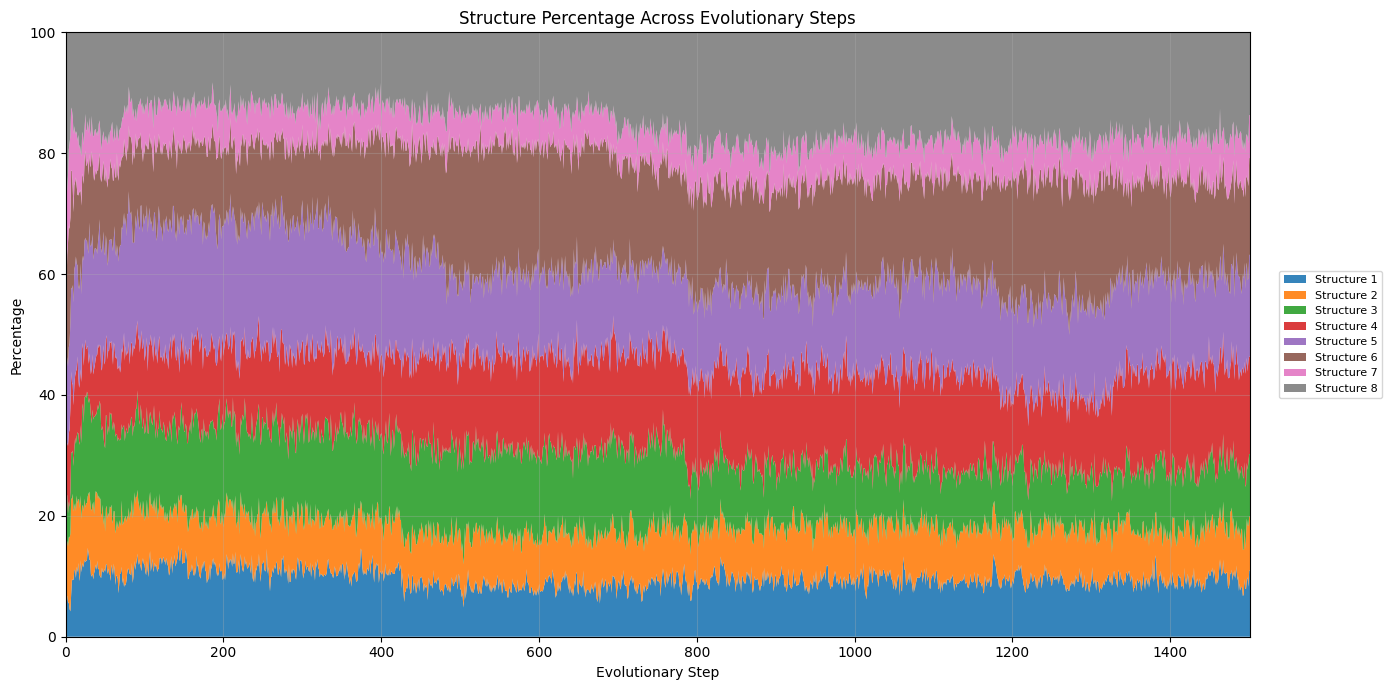

In [ ]:
pattern = path.join('..', 'results', no_int_ex_name, '**', 'structure.csv')
files = glob(pattern, recursive=True)

# structure_counts_aggregated[step] = Counter({structure_index: total_count_across_all_runs})
structure_counts_aggregated = []

for file in files:
    df = pd.read_csv(file, header=None)

    for step_idx, row in df.iterrows():
        while len(structure_counts_aggregated) <= step_idx:
            structure_counts_aggregated.append(Counter())

        row_text = str(row.iloc[0]).strip()
        if row_text == '' or row_text.lower() == 'nan':
            continue

        indices = [idx for idx in re.split(r'\s+', row_text) if idx != '']
        structure_counts_aggregated[step_idx].update(indices)

print(f'Number of evolutionary steps aggregated: {len(structure_counts_aggregated)}')

# Build a consistent list of all structures that appeared
all_structures = sorted({s for c in structure_counts_aggregated for s in c.keys()}, key=lambda x: int(x))
n_steps = len(structure_counts_aggregated)
x = np.arange(n_steps)

# percentages[i, t] = percentage of structure i at step t
percentages = np.zeros((len(all_structures), n_steps), dtype=float)

for t, counter in enumerate(structure_counts_aggregated):
    total = sum(counter.values())
    if total == 0:
        continue
    for i, structure in enumerate(all_structures):
        percentages[i, t] = 100.0 * counter.get(structure, 0) / total

# Stacked area chart
plt.figure(figsize=(14, 7))
plt.stackplot(x, *percentages, labels=[f'Structure {s}' for s in all_structures], alpha=0.9)
plt.title('Structure Percentage Across Evolutionary Steps')
plt.xlabel('Evolutionary Step')
plt.ylabel('Percentage')
plt.xlim(0, n_steps - 1)
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
from fitness.minimise_causal_arrows import count_causal_arrows, structure_to_id, structure_to_id_undirected, perm_to_mapping
p = """
V1 = gm([1.0e0, +8.2e0, 0.2e0], [5.6e1, +4.9e0, 1.5e0], [0.0e0, -6.8e1, 6.4e1]);
V2 = -8.7e0 ;
V2 = V2 + uniform([+7.2e0, 2.1e1], 2);
V3 =  +2.0e0;
V3 = V3 + gm([7.3e0, +8.1e0, 2.0e0]);
"""
perm = 6

data_var_list, scm = dgp.get_vars('common_cause')
v_to_data = perm_to_mapping(perm, data_var_list)
print(v_to_data)
num, edges =count_causal_arrows(p)

#structure_id = structure_to_id(edges)
structure_id = structure_to_id_undirected(edges, perm, data_var_list)
print(structure_id)

{'V1': 'T', 'V2': 'C', 'V3': 'F'}
1
